In [1]:
import rasterio as rs
import numpy as np
import matplotlib.pyplot as plt

import geopandas as gpd
import shapely
import fiona
import pandas as pd
import json
import os
from glob import glob
from shapely.geometry import Polygon

from sklearn.metrics import f1_score
from sarpy.visualization.remap import density
from rasterio.windows import from_bounds
from shapely.geometry import box

from sarpy.visualization.remap import density, brighter

import geopandas as gpd
import fiona
from tqdm import tqdm
from shapely import make_valid
from datetime import datetime
from datetime import timedelta
import lightgbm as lgb

In [2]:
import cv2
from sklearn.metrics import auc, f1_score
from sklearn.metrics import roc_curve, auc, precision_recall_curve, precision_score
from sklearn.model_selection import train_test_split
import random

plt.style.use('dark_background')

In [ ]:
def compute_feats(df_):

    # col_names = [f'e{i+1}' for i in range(192)]
    col_names=[]
    if NUM_IMG_CHANNELS == 8:
        col_names.extend(["Coastal_B", "B", "GI", "G","Y", "R", "RE", "NIR"])
    elif NUM_IMG_CHANNELS == 4:
        col_names.extend(['B', 'G', 'R', 'NIR'])
    else:
        raise NotImplementedError
    

    df = pd.DataFrame(df_, columns=col_names)

    df['NDVI'] = (df['NIR'] - df['R']) / (df['NIR'] + df['R'] + 1e-08) 
    df['GNDVI'] = (df['NIR'] - df['G']) / (df['NIR'] + df['G'] + 1e-08) 
    df['RGI'] = df['R'] / (df['G'] + 1e-08) 
    
    return df

# Read embeddings

Read the embedding files from the Olmo-exported directories and concatenate into train/val/test sets that were originally created on a spatial split basis from Olmo (included in the meta tag)

In [ ]:
emb_files = sorted(glob(f'usfs/oerun/dataset/windows/spatial_split_10km/task_*_polygon_window/layers/embeddings/embeddings/geotiff.tif'))

NUM_IMG_CHANNELS = 8
NUM_CHAN = NUM_IMG_CHANNELS + 192

df_train = np.zeros((0,NUM_CHAN))
y_train = np.zeros((0,1))
df_val = np.zeros((0,NUM_CHAN))
y_val = np.zeros((0,1))
df_test = np.zeros((0,NUM_CHAN))
y_test = np.zeros((0,1))

for f_emb in emb_files:
    
    # target_str = 'sentinel2_l2a_t0/B02_B03_B04_B08/geotiff.tif' # 'doveR/b01_b02_b03_b04/geotiff.tif'
    target_str = 'superdove_2years_after/b01_b02_b03_b04_b05_b06_b07_b08/geotiff.tif'
    f_img = f_emb.replace('embeddings/embeddings/geotiff.tif', target_str)
    
    if os.path.exists(f_img):
    
        base_dir = '/'.join(f_img.split('/')[:-4])
        meta_json = json.load(open(base_dir+'/metadata.json','r'))    
        split = meta_json['options']['split']

        img_label = rs.open(f_img.replace(target_str, 'label/label/geotiff.tif')).read(1)

        img_rs = rs.open(f_img)
        img_multi = np.transpose(img_rs.read(list(range(1,NUM_IMG_CHANNELS+1))), (1,2,0))
        img_multi = img_multi.reshape((-1,NUM_IMG_CHANNELS))

        img_rs = rs.open(f_emb)
        img_emb = np.transpose(img_rs.read(list(range(1,192+1))), (1,2,0))
        img_emb = cv2.resize(img_emb, img_label.shape[:2][::-1], interpolation=cv2.INTER_CUBIC)
        img_emb = img_emb.reshape((-1,192))

        img_concat = np.concatenate((img_emb, img_multi), axis=1)

        if split=='train':
            df_train = np.concatenate((df_train, img_concat))
            y_train = np.concatenate((y_train, img_label.ravel()[...,None]))
        elif split=='val':
            df_val = np.concatenate((df_val, img_concat))
            y_val = np.concatenate((y_val, img_label.ravel()[...,None]))
        elif split=='test':
            df_test = np.concatenate((df_test, img_concat))
            y_test = np.concatenate((y_test, img_label.ravel()[...,None]))
    else:
        print('DNE')

In [ ]:
df_data = np.concatenate((df_train, df_val, df_test), axis=0)
df_label = np.concatenate((y_train, y_val, y_test), axis=0)

In [ ]:
SAMPLE_SPLIT = False

if SAMPLE_SPLIT:
    all_idxs = np.arange(df_data.shape[0])
    random.shuffle(all_idxs)

    train_idxs = all_idxs[:int(0.5*all_idxs.shape[0])]
    val_idxs = all_idxs[int(0.5*all_idxs.shape[0]):int(0.8*all_idxs.shape[0])]
    test_idxs = all_idxs[int(0.8*all_idxs.shape[0]):]

    df_train = df_data[train_idxs]
    y_train = df_label[train_idxs]
    df_val = df_data[val_idxs]
    y_val = df_label[val_idxs]
    df_test = df_data[test_idxs]
    y_test = df_label[test_idxs]

In [360]:
df_train[np.isinf(df_train)] = 0.
df_val[np.isinf(df_val)] = 0.
df_test[np.isinf(df_test)] = 0.

df_train[np.isnan(df_train)] = 0.
df_val[np.isnan(df_val)] = 0.
df_test[np.isnan(df_test)] = 0.

In [362]:
# compute image indices (NDVI, GNDVI, RGI)

df_train = compute_feats(df_train)
df_val = compute_feats(df_val)
df_test = compute_feats(df_test)

In [363]:
# standardize the input features to stabilize training

from sklearn import preprocessing
scaler = preprocessing.StandardScaler()
df_train = scaler.fit_transform(df_train)
df_val = scaler.transform(df_val)
df_test = scaler.transform(df_test)

In [364]:
# add names for all feature channels to facilitate tracking

col_names = [f'e{i+1}' for i in range(192)]
# col_names=[]
if NUM_IMG_CHANNELS == 8:
    additional_feats = ["Coastal_B", "B", "GI", "G","Y", "R", "RE", "NIR", 'NDVI', 'GNDVI', 'RGI']
elif NUM_IMG_CHANNELS == 4:
    additional_feats = ['B', 'G', 'R', 'NIR', 'NDVI', 'GNDVI', 'RGI']
else:
    raise NotImplementedError

col_names.extend(additional_feats)

df_train = pd.DataFrame(df_train, columns=col_names)
df_val = pd.DataFrame(df_val, columns=col_names)
df_test = pd.DataFrame(df_test, columns=col_names)

# LGBM training

Fit the boosting model on image features with embeddings

In [ ]:
params = {
          'bagging_fraction': 0.9111111111111111,
          'bagging_freq': 3,
          'colsample_bytree': 0.6416528309552162,
          'learning_rate': 1e-01,
          'max_depth': -1,
          'min_child_samples': 234,
          'min_child_weight': 0.01,
          'min_data_in_leaf': 24,
          'num_leaves': 114,
          'reg_alpha': 1,
          'reg_lambda': 1,
          'subsample': 0.8037527845774377,
          'n_estimators' : 1000,
          'n_jobs': 24,
          'is_unbalance' : True,
          'objective':'binary',
          'num_class': 1,
          'verbose':2
         }

lgb_train = lgb.Dataset(df_train,
                        y_train)
                        # weight=sw_train)

lgb_valid = lgb.Dataset(df_val,
                        y_val)
                        # weight=sw_val)

evals_result = {}
lgb_model = lgb.train(params,
                      lgb_train,
                      valid_sets=[lgb_valid])

### Predict from the fitted model

In [366]:
y_pred_train = lgb_model.predict(df_train)
y_pred_val = lgb_model.predict(df_val)
y_pred_test = lgb_model.predict(df_test)

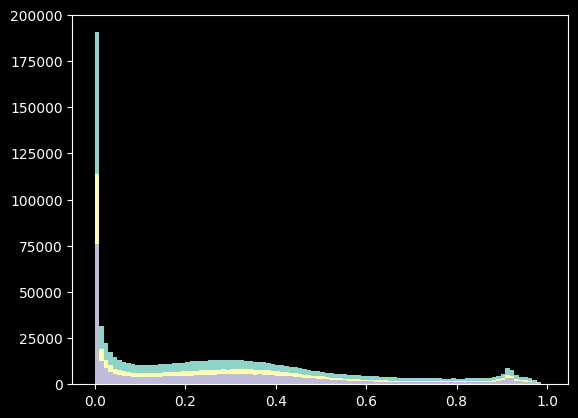

In [367]:
plt.hist(y_pred_train, bins=100);
plt.hist(y_pred_val, bins=100);
plt.hist(y_pred_test, bins=100);

### Evalation

Evaluate the validation and test set by computing the PRAUC and F1 scores

In [368]:
threses = np.linspace(y_pred_test.min(), y_pred_test.max(),100)
f1s=[]
for t in threses:
    f1s.append(f1_score(y_test, y_pred_test > t))

In [ ]:
np.max(f1s)

np.float64(0.4706072438400431)

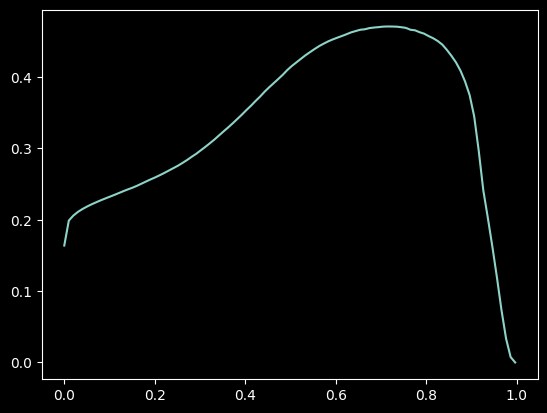

In [376]:
plt.plot(threses, f1s)

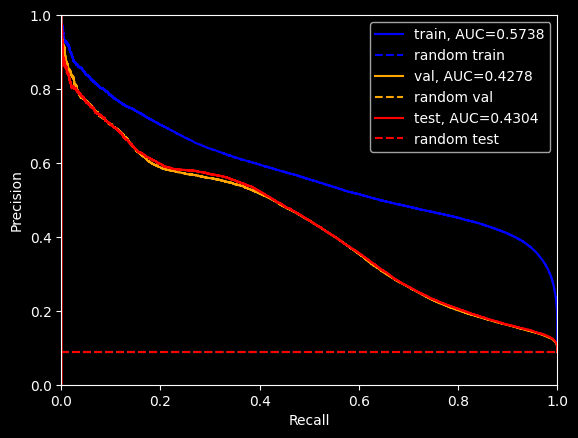

In [377]:
p, r, ts = precision_recall_curve(y_train, y_pred_train)
p_val, r_val, t_val = precision_recall_curve(y_val, y_pred_val)
p_test, r_test, t_test = precision_recall_curve(y_test, y_pred_test)

_, (num_neg_train, num_pos_train) = np.unique(y_train, return_counts=True)
_, (num_neg, num_pos) = np.unique(y_val>0, return_counts=True)
_, (num_neg_test, num_pos_test) = np.unique(y_test, return_counts=True)

random_train = num_pos_train / (num_neg_train + num_pos_train)
random_val = num_pos / (num_neg + num_pos)
random_test = num_pos_test / (num_neg_test + num_pos_test)

plt.plot(r, p, label=f'train, AUC={auc(r, p):0.4f}', color='blue')
plt.axhline(random_train, label='random train', color='blue', ls='--')

plt.plot(r_val, p_val, label=f'val, AUC={auc(r_val, p_val):0.4f}', color='orange')
plt.axhline(random_val, label='random val', color='orange', ls='--')

plt.plot(r_test, p_test, label=f'test, AUC={auc(r_test, p_test):0.4f}', color='r')
plt.axhline(random_test, label='random test', color='r', ls='--')

plt.xlim([0.0,1.0])
plt.ylim([0.0,1.0])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()

# Feature Importance

Plot the relative importance of each feature used in the boosting model

In [381]:
import seaborn as sns

In [382]:
fcols = df_train.columns

feature_importance = pd.DataFrame()
fold_importance = pd.DataFrame()
fold_importance["feature"] = fcols
fold_importance["importance"] = lgb_model.feature_importance()
feature_importance = pd.concat([feature_importance, fold_importance], axis=0)

/tmp/ipykernel_113525/787871714.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=best_features, palette="viridis");


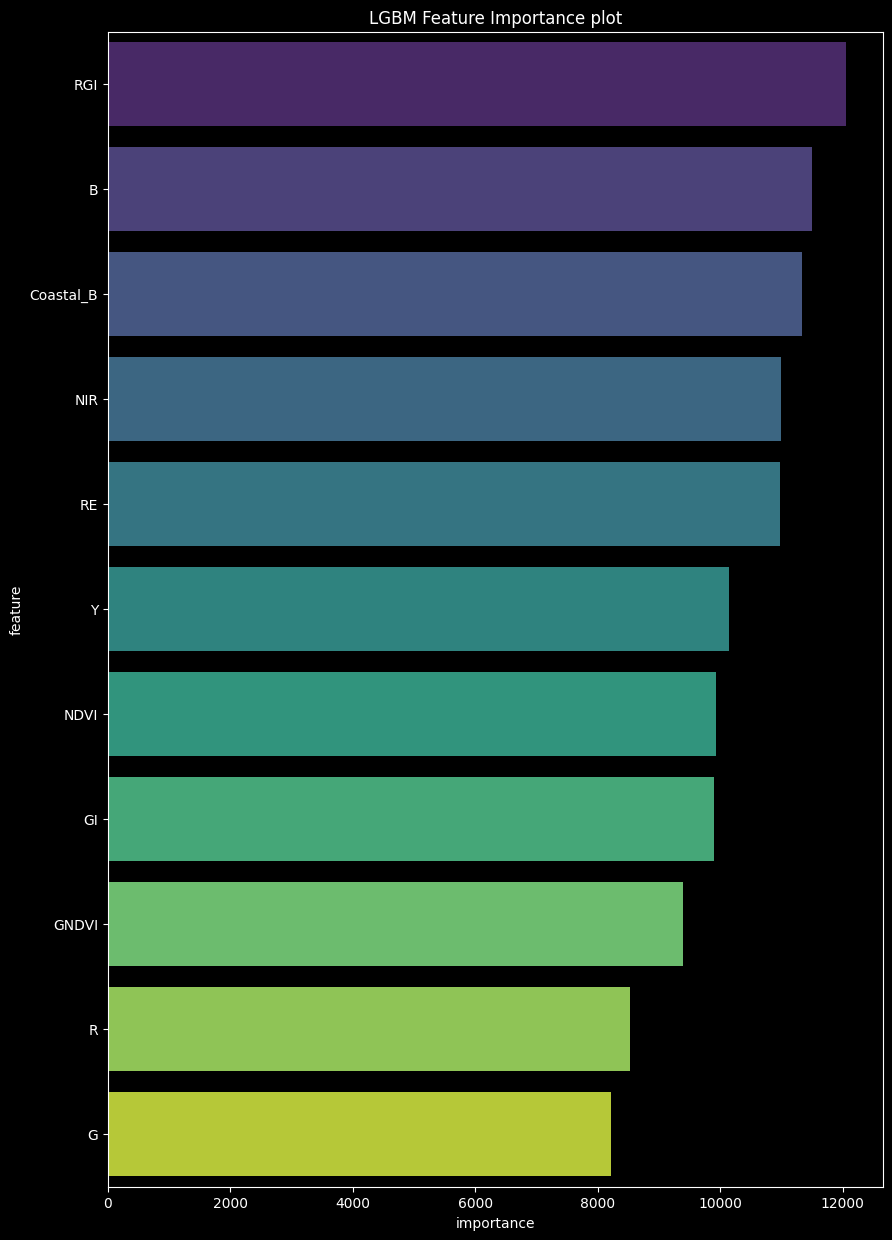

In [383]:
cols = feature_importance[["feature", "importance"]].groupby("feature").mean().sort_values(
            by="importance", ascending=False)[:100].index

best_features = feature_importance.loc[feature_importance.feature.isin(cols)]
best_features = best_features.sort_values(by="importance", ascending=False)

plt.figure(figsize=(10, 15));
sns.barplot(x="importance", y="feature", data=best_features, palette="viridis");
plt.title('LGBM Feature Importance plot');